# NBA Draft Prediction 


In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import utils
import config
import train
import model as nn

## 1. Carga y preprocesado de datos


In [5]:
data = utils.prepare_data()
print("Datos cargados correctamente:")
print(f"  X_train shape: {data['X_train'].shape} | y_train shape: {data['y_train'].shape}")
print(f"  X_val shape:   {data['X_val'].shape} | y_val shape:   {data['y_val'].shape}")
print(f"  X_test shape:  {data['X_test'].shape} | y_test shape:  {data['y_test'].shape}")
print(f"  X_2026 shape:  {data['X_2026'].shape}")
print(f"\nCaracterísticas seleccionadas (Top {len(data['feature_cols'])}):")
print(data['feature_cols'])

Datos cargados correctamente:
  X_train shape: (1574, 40) | y_train shape: (1574, 1)
  X_val shape:   (194, 40) | y_val shape:   (194, 1)
  X_test shape:  (197, 40) | y_test shape:  (197, 1)
  X_2026 shape:  (94, 40)

Características seleccionadas (Top 40):
['Age', 'Experiencia universitaria_Senior', 'Experiencia universitaria_Freshman', 'eFG%_relative_to_pos', 'STL_per40_relative_to_pos', 'STL_per40', 'PTS_per40', 'Altura descalzo (Cm)_relative_to_pos', 'Experiencia universitaria_Sophomore', 'eFG%', 'PTS_per40_relative_to_pos', 'STL', 'Alcance de pie (Cm)_relative_to_pos', '2P%', 'Salto vertical - En carrera (cm)_relative_to_pos', 'Envergadura (Cm)_relative_to_pos', 'G', 'PTS', 'GS', 'Salto vertical - Estático (cm)_relative_to_pos', 'Salto vertical - Estático (cm)', 'Salto vertical - En carrera (cm)', 'BLQ_per40_relative_to_pos', 'Prueba de agilidad (s)', 'TC%', 'Liga_Grouped_Desconocido', 'REB_per40_relative_to_pos', 'BLQ', 'Sprint de tres cuartos (s)', 'Posición_Desconocido', '3P%_r

## 2. Entreno el Ensamble Óptimo (Experimento 1)

Entrenando Ensamble de Modelos (Semillas: [42, 107, 999, 7, 88]):
  -> Semilla 42 finalizada. Mejor métrica (rbo): RBO: 0.5044
  -> Semilla 107 finalizada. Mejor métrica (rbo): RBO: 0.5600
  -> Semilla 999 finalizada. Mejor métrica (rbo): RBO: 0.5101
  -> Semilla 7 finalizada. Mejor métrica (rbo): RBO: 0.5832
  -> Semilla 88 finalizada. Mejor métrica (rbo): RBO: 0.4935


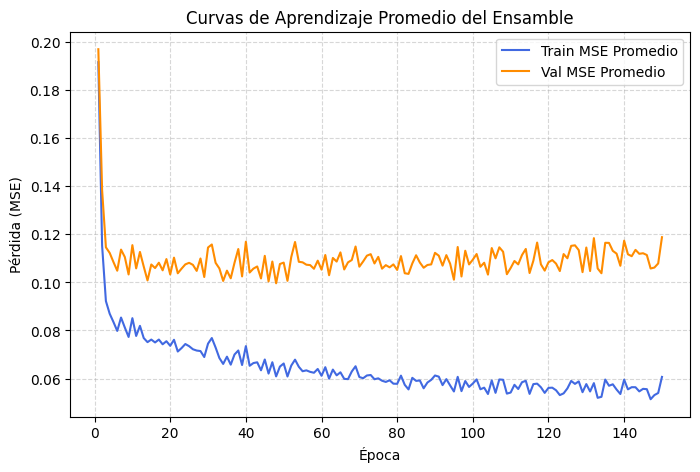

In [6]:
X_train, y_train = data['X_train'], data['y_train']
X_val, y_val = data['X_val'], data['y_val']
val_meta = data['val_meta']

ensemble_weights = {}
all_seed_train_losses = []
all_seed_val_losses = []

print(f'Entrenando Ensamble de Modelos (Semillas: {config.ENSEMBLE_SEEDS}):')

for seed in config.ENSEMBLE_SEEDS:
    np.random.seed(seed)
    model_seed = train.build_model(X_train.shape[1])
    opt_seed = nn.Adam(model_seed.params, lr=config.LEARNING_RATE, weight_decay=config.WEIGHT_DECAY)
    
    best_val_rbo = -1.0
    best_val_loss = float('inf')
    best_val_rbo_checkpoint = -1.0
    best_w = {}
    train_losses = []
    val_losses = []
    
    for epoch in range(1, config.EPOCHS + 1):
        indices = np.arange(len(X_train))
        np.random.shuffle(indices)
        X_train_sh = X_train[indices]
        y_train_sh = y_train[indices]
        
        model_seed.set_mode('train')
        for start_idx in range(0, len(X_train), config.BATCH_SIZE):
            end_idx = min(start_idx + config.BATCH_SIZE, len(X_train))
            X_batch = X_train_sh[start_idx:end_idx]
            y_batch = y_train_sh[start_idx:end_idx]
            
            preds = model_seed.forward(X_batch)
            weights = 1.0 + config.LOSS_WEIGHT_FACTOR * y_batch
            dLoss = 2.0 * (preds - y_batch) * weights / len(X_batch)
            
            opt_seed.zero_grad()
            model_seed.backward(dLoss)
            opt_seed.step()
            
        # Evaluar época
        model_seed.set_mode('test')
        tr_preds = model_seed.forward(X_train)
        train_losses.append(np.mean((tr_preds - y_train) ** 2))
        
        v_preds = model_seed.forward(X_val)
        val_loss_epoch = np.mean((v_preds - y_val) ** 2)
        val_losses.append(val_loss_epoch)
        
        if epoch % 5 == 0 or epoch == 1 or epoch == config.EPOCHS:
            val_rbo, _ = utils.evaluate_model_rbo(val_meta, v_preds.flatten())
            
            is_best = False
            if config.CHECKPOINT_METRIC == 'loss':
                if val_loss_epoch < best_val_loss:
                    best_val_loss = val_loss_epoch
                    is_best = True
            else:
                if val_rbo > best_val_rbo:
                    best_val_rbo = val_rbo
                    is_best = True
                    
            if is_best:
                best_val_rbo_checkpoint = val_rbo
                best_w = {}
                linear_idx = 0
                for layer in model_seed.layers:
                    if isinstance(layer, nn.Linear):
                        best_w[f'W_{linear_idx}'] = layer.W.val.copy()
                        best_w[f'b_{linear_idx}'] = layer.b.val.copy()
                        linear_idx += 1
                        
    metric_str = f'MSE: {best_val_loss:.5f} (RBO: {best_val_rbo_checkpoint:.4f})' if config.CHECKPOINT_METRIC == 'loss' else f'RBO: {best_val_rbo_checkpoint:.4f}'
    print(f'  -> Semilla {seed} finalizada. Mejor métrica ({config.CHECKPOINT_METRIC}): {metric_str}')
    all_seed_train_losses.append(train_losses)
    all_seed_val_losses.append(val_losses)
    
    # Guardar mejores pesos del modelo
    for k, v in best_w.items():
        ensemble_weights[f'{k}_seed_{seed}'] = v
        
# Graficar curva de pérdida promedio del ensamble
plt.figure(figsize=(8, 5))
plt.plot(range(1, config.EPOCHS + 1), np.mean(all_seed_train_losses, axis=0), label='Train MSE Promedio', color='royalblue')
plt.plot(range(1, config.EPOCHS + 1), np.mean(all_seed_val_losses, axis=0), label='Val MSE Promedio', color='darkorange')
plt.xlabel('Época')
plt.ylabel('Pérdida (MSE)')
plt.title('Curvas de Aprendizaje Promedio del Ensamble')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Evaluar el ensamble promedio en Validación y Test
Evaluo la precisión final de RBO combinando las predicciones promediadas del ensamble.

In [8]:
# Evaluar en Validación
val_preds = train.predict_ensemble(X_val, ensemble_weights, X_train.shape[1])
val_rbo, val_rbo_by_year = utils.evaluate_model_rbo(val_meta, val_preds)
print("=== RENDIMIENTO DEL ENSAMBLE EN VALIDACIÓN ===")
print(f"RBO Promedio: {val_rbo:.4f}")
for year, score in val_rbo_by_year.items():
    print(f"  Año {year} RBO: {score:.4f}")

# Evaluar en Test
X_test = data['X_test']
test_preds = train.predict_ensemble(X_test, ensemble_weights, X_train.shape[1])
test_rbo, test_rbo_by_year = utils.evaluate_model_rbo(data['test_meta'], test_preds)
print("\n=== RENDIMIENTO DEL ENSAMBLE EN PRUEBA (TEST) ===")
print(f"RBO Promedio: {test_rbo:.4f}")
for year, score in test_rbo_by_year.items():
    print(f"  Año {year} RBO: {score:.4f}")

=== RENDIMIENTO DEL ENSAMBLE EN VALIDACIÓN ===
RBO Promedio: 0.5462
  Año 2022 RBO: 0.6266
  Año 2023 RBO: 0.4658

=== RENDIMIENTO DEL ENSAMBLE EN PRUEBA (TEST) ===
RBO Promedio: 0.5062
  Año 2024 RBO: 0.3679
  Año 2025 RBO: 0.6445


## 3. Predicción del Draft 2026 y Guardo en CSV


In [9]:
# Predecir puntuaciones para 2026
X_2026 = data['X_2026']
preds_2026 = train.predict_ensemble(X_2026, ensemble_weights, X_train.shape[1])

# Cargar datos crudos y visualizar
raw_2026_basics = pd.read_excel('Datasets/Prospects_2026_BDS.xlsx', sheet_name='Datos básicos')
results_2026 = data['2026_meta'].copy()
results_2026['Pred_Score'] = preds_2026

results_display = pd.merge(raw_2026_basics, results_2026[['Nombre del jugador', 'Pred_Score']], on='Nombre del jugador')
results_display['Age'] = 2026 - pd.to_datetime(results_display['Nacimiento'], errors='coerce', format='mixed').dt.year
results_display = results_display.sort_values(by='Pred_Score', ascending=False).reset_index(drop=True)
results_display['Predicted_Pick'] = results_display.index + 1

# Guardar predicciones definitivas en CSV
results_display.to_csv('predicted_2026_draft.csv', index=False)
print("¡Predicciones guardadas con éxito en predicted_2026_draft.csv!")

print("\n=== CLASIFICACIÓN DEL DRAFT 2026 POR EL ENSAMBLE ===")
results_display[['Predicted_Pick', 'Nombre del jugador', 'Age', 'Posición', 'Liga', 'Equipo', 'Pred_Score']].head(25)

¡Predicciones guardadas con éxito en predicted_2026_draft.csv!

=== CLASIFICACIÓN DEL DRAFT 2026 POR EL ENSAMBLE ===


,Predicted_Pick,Nombre del jugador,Age,Posición,Liga,Equipo,Pred_Score
0,1,AJ Dybantsa,19,F,College,Brigham Young,0.767649
1,2,Cameron Boozer,19,F,College,Duke,0.764840
2,3,Darius Acuff,20,G,College,Arkansas,0.745141
3,4,Keaton Wagler,19,G,College,Illinois,0.725436
4,5,Kingston Flemings,19,G,College,Houston,0.719861
5,6,Ebuka Okorie,19,G,College,Stanford,0.715551
6,7,Aday Mara,21,C,College,Michigan,0.712830
7,8,Caleb Wilson,20,F,College,North Carolina,0.708416
8,9,Nate Ament,20,F,College,Tennessee,0.706369
9,10,Darryn Peterson,19,G,College,Kansas,0.705959
